.<center> 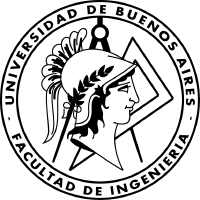



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP8: Modelo de Lenguaje y Sistema de Recomendación**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Modelo de Lenguaje

Se desea diseñar un buscador de títulos de películas, de manera que si el usuario comete algún error u omisión cuando lo escribe, el buscador pueda entender.

### (a.1)

Se carga la base de datos *anime.csv*. Esta base muestra la puntuación dada por usuarios a ciertas series de anime. En las columnas se definen a los usuarios y en las filas a las series. Se utiliza una calificación del 1 al 10 y se asigna -1 cuando un usuario no vió una serie.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/anime.csv"
anime=pd.read_csv(url)
print(anime.head)

<bound method NDFrame.head of                                            title  680973  682775  682809  \
0                              "Deji" Meets Girl    -1.0     8.0     7.0   
1                                 "Ippon" again!    -1.0    -1.0    -1.0   
2              'Tis Time for "Torture," Princess    -1.0     8.0     7.0   
3     'Tis Time for "Torture," Princess Season 2    -1.0    -1.0    -1.0   
4          0 Years Old Child Starting Dash Story    -1.0     8.0    -1.0   
...                                          ...     ...     ...     ...   
2961                            gdgd men's Party    -1.0    -1.0    -1.0   
2962                              makuranodanshi    -1.0    -1.0    -1.0   
2963                                    number24    -1.0    -1.0    -1.0   
2964                    selector infected WIXOSS    -1.0    -1.0    -1.0   
2965                      selector spread WIXOSS    -1.0    -1.0    -1.0   

      684730  684840  684862  685362  686426  686489  ...

### (a.2)


Se carga el modelo de lenguaje. Este modelo posee una arquitectura transformer llamada XLM-Roberta. En lugar de trabajar palabra por palabra, este transformer utiliza subword tokens (utilizando la raíz de las
palabras con una perspectiva semántica).

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')


### (a.3)

Se realiza un procesador de texto que convierte las mayúsculas en minúsculas y que unifica espacios en blanco. Luego, se procesan los nombres de las series.

In [ ]:
def procesador(texto):
    texto = texto.lower()
    while "  " in texto:
        texto = texto.replace("  ", " ")
    texto = texto.strip()
    return texto

anime['title'] = anime['title'].apply(procesador)


### (a.4)

En este bloque se calcula el embedding del texto "Attack on Titan" utilizando el modelo de lenguaje ya definido. El embedding es un vector numérico de alta dimensión que representa el significado semántico del texto, de modo que títulos con significados similares tienen representaciones cercanas en el espacio vectorial. Luego, se muestra la cantidad de componentes del vector resultante, indicando cuántas dimensiones utiliza el modelo para describir cada título.

In [ ]:
texto_1 = "Attack on Titan"
embedding_1 = model.encode(texto_1)
print("Dimensión del embedding:", embedding_1.shape)


Dimensión del embedding: (768,)


### (a.5)

Se implementa la función *sim_coseno* que calcula la similitud coseno. La similitud coseno se define como el coseno del ángulo entre dos vectores:

$$SC(u,v)=\frac{u\cdot v}{||u||\ ||v||}$$

In [ ]:
import numpy as np

def sim_coseno(a, b):
    a = np.array(a).squeeze()
    b = np.array(b).squeeze()
    num = np.dot(a, b)
    den = np.linalg.norm(a) * np.linalg.norm(b)
    return float(num / den)

### (a.6)

Se implementa una función de búsqueda semántica que, dado un texto de entrada, devuelve las $k$ series cuyos títulos presentan la mayor similitud con dicho texto. Para ello, el buscador convierte el texto ingresado en su embedding correspondiente y calcula la similitud del coseno con los embeddings de todas las series en la base de datos. Finalmente, ordena los resultados según el grado de similitud y devuelve los títulos más cercanos.



In [ ]:
def buscador(texto, k):
    texto_proc = procesador(texto)
    embedding_texto = model.encode(texto_proc)
    anime['similarity'] = anime['embedding'].apply(lambda emb: sim_coseno(embedding_texto, emb))
    resultados = anime.sort_values(by='similarity', ascending=False).head(k)
    return resultados[['title', 'similarity']]


### (a.7)

Se verifica si ya existe un archivo con los embeddings previamente calculados (embeddings.npy) para evitar reprocesar toda la base de datos. En caso de no existir, se generan los embeddings de los títulos utilizando el modelo de lenguaje y se guardan en un archivo para uso futuro. Luego, se asocian los embeddings a cada serie en el DataFrame y se prueba el buscador consultando el término “Giant” con $k=15$.

In [ ]:
import os
import numpy as np

if os.path.exists('embeddings.npy'):
    embeddings = np.load('embeddings.npy', allow_pickle=True)
else:
    textos = anime['title'].tolist()
    embeddings = model.encode(textos, batch_size=32, show_progress_bar=True)
    np.save('embeddings.npy', embeddings)

anime['embedding'] = list(embeddings)

In [ ]:
print(buscador("Giant", k=15))

                       title  similarity
842            giant killing    0.656904
841      giant beasts of ars    0.654885
2084            super hxeros    0.552468
1541              megane-bu!    0.551769
2005              re:monster    0.543036
1848             overlord ii    0.541113
1539               megalobox    0.535180
2314               super cub    0.534595
1847                overlord    0.534339
2502  the great warrior wall    0.520100
384               bullbuster    0.519549
646        dragon ball super    0.515048
976             heavy object    0.509278
1903          plus-sized elf    0.489508
2388         tearmoon empire    0.475996


Entre las sugerencias se destacan dos títulos que contienen explícitamente la palabra “giant”: *Giant Killing* y *Giant Beasts of Ars*. Además, aparecen otros títulos que, aunque no incluyen el término de forma literal, se relacionan con su significado, ya sea por asociarse con el tamaño, el poder o la grandeza, como *The Great Warrior Wall*, *Super Hxeros*, *Overlord*, *Overlord II*, *Dragon Ball Super* y *Megalobox*. Finalmente, se observan títulos con sinónimos o ideas semánticamente afines a “giant”, como *Plus-Sized Elf* y *Heavy Project*.

### (a.8)

Se implementa una clase llamada *BuscadorAnime* que encapsula el funcionamiento del buscador de títulos. La clase carga los datos, procesa los textos para mantener un formato uniforme, calcula los embeddings de cada título utilizando un modelo de lenguaje y permite buscar las series más similares a una cadena de texto dada. El método buscador devuelve las $k$ series con mayor similitud coseno respecto al texto ingresado.

In [ ]:
class BuscadorAnime:
    def __init__(self, data_path):
        self.model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
        self.data = pd.read_csv(data_path)
        self.data['title'] = self.data['title'].apply(self.procesador)
        self.data['embedding'] = self.data['processed'].apply(lambda x: self.model.encode(x))

    def procesador(self, texto):
        texto = texto.lower()
        while "  " in texto:
            texto = texto.replace("  ", " ")
            texto = texto.strip()
        return texto

    def sim_coseno(self, a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

    def buscador(self, texto, k):
        texto_proc = self.procesador(texto)
        embedding_texto = self.model.encode(texto_proc)
        self.data['similarity'] = self.data['embedding'].apply(lambda emb: self.sim_coseno(embedding_texto, emb))
        resultados = self.data.sort_values(by='similarity', ascending=False).head(k)[['title', 'similarity']]
        return resultados

## (b) Sistema de Recomendación

### (b.1)

El riesgo empírico regularizado que se utiliza en los filtros colaborativos basados en factorización matricial es la función de costo $J$:

$$J(X,Θ)=\frac{1}{2}\sum_{i,j\in\mathcal{R}}(\theta_j^T\cdot x_i-y_{i,j})^2+\frac{\lambda}{2}\bigg(\sum_{i=1}^{n_\text{items}}||x_i||^2+\sum_{j=1}^{n_\text{users}}||\theta_j||^2\bigg)$$

donde $X=[x_1,\dots,x_{n_\text{items}}]^T$ es la matriz de series

$\Theta=[\theta_1,\dots,\theta_{n_\text{users}}]^T$ es la matriz de usuarios


El gradiente parcial con respecto a un vector de ítem específico $x_i$ es:

$$\nabla_{x_i}J=\sum_{(i,j)\in\mathcal{R}}(\theta_j^Tx_i-y_{i,j})\cdot \theta_j+\lambda x_i$$

El gradiente parcial con respecto a un vector de usuario específico $\theta_j$ es:

$$\nabla_{\theta_j}J=\sum_{(i,j)\in\mathcal{R}}(\theta_j^Tx_i-y_{i,j})\cdot x_i+\lambda \theta_j$$

Los resultados pueden ser expresados en su forma vectorizada como:

$$\nabla_XJ=E\cdot\Theta+\lambda X$$

$$\nabla_\Theta J=E^T\cdot X + \lambda \Theta$$

En donde, se define la matriz de errores como:

$$E=\begin{cases}(\theta_j^T\cdot x_i-y_{i,j})&(i,j)\in\mathcal{R}\\
0&(i,j)\notin \mathcal{R}\end{cases}$$

### (b.2)

Se agrega un nuevo usuario a la base de datos. Este tiene id = "123456". Se agregan 10 calificaciones de series usando el buscador con ciertas palabras. A cada anime se le asigna una calificación random entre 1 y 10.

In [ ]:
names = ["titan", "naruto", "death", "dragon", "hero", "note", "love", "giant", "ghost", "samurai"]
user_id = '123456'

new_user = np.full((anime.shape[0], 1), -1.0)

for name in names:
  result = buscador(name, k=1)
  title = result['title'].values[0]
  idx_serie = anime[anime['title'] == title].index[0]
  score = float(np.random.randint(1, 10))
  print(f"La puntuación de {title} es: {score}")
  new_user[idx_serie, 0] = score

anime[user_id] = new_user


El rating de attack on titan es: 6.0
El rating de naruto (shinsaku anime) es: 6.0
El rating de angels of death es: 9.0
El rating de dragon collection es: 8.0
El rating de heroman es: 1.0
El rating de tesla note es: 8.0
El rating de a condition called love es: 4.0
El rating de giant killing es: 3.0
El rating de mf ghost es: 4.0
El rating de samurai warriors es: 2.0


### (b.3)

Se implementa la clase *CollaborativeFilter*, que entrena un sistema de recomendación basado en filtrado colaborativo utilizando gradiente descendente.
El modelo factoriza la matriz de calificaciones $Y$ en dos matrices latentes:

* $X$: representa las características latentes de los items (series).

* $\Theta$: representa las preferencias latentes de los usuarios.

Durante el entrenamiento, el método *fit* ajusta ambas matrices minimizando el error cuadrático regularizado entre las predicciones y las calificaciones reales.
El método *predict* reconstruye las calificaciones estimadas, mientras que *get_loss_history* permite visualizar la evolución del riesgo empírico regularizado a lo largo de las iteraciones.

In [ ]:
class CollaborativeFilter:
    def __init__(self, n_items, n_users, n_latent, lr, lmbda, n_iter):
        self.n_latent = n_latent # Dimensión espacio latente
        self.lr = lr             # Learning rate
        self.lmbda = lmbda       # Lambda
        self.n_iter = n_iter     # N° iteraciones
        self.n_items = n_items   # Cantidad de peliculas
        self.n_users = n_users   # Cantidad de usuarios

        # Inicialización X y Theta
        self.X = np.random.randn(self.n_items, self.n_latent) * 0.01
        self.Theta = np.random.randn(self.n_users, self.n_latent) * 0.01
        self.loss_history = []

    def fit(self, Y, R):
        for it in range(self.n_iter):
            predictions = self.X @ self.Theta.T
            error = (predictions - Y) * R
            # Costo
            loss = 0.5 * np.sum(error ** 2) + (self.lmbda / 2) * (np.sum(self.X ** 2) + np.sum(self.Theta ** 2))
            self.loss_history.append(loss)
            # Gradientes
            X_grad = error @ self.Theta + self.lmbda * self.X
            Theta_grad = error.T @ self.X + self.lmbda * self.Theta
            # Actualización
            self.X -= self.lr * X_grad
            self.Theta -= self.lr * Theta_grad

    def predict(self):
        return self.X @ self.Theta.T

    def get_loss_history(self):
        return self.loss_history

Se seleccionan las columnas de calificaciones y se crean dos matrices: $Y$, con las calificaciones reales (con valores faltantes reemplazados por 0), y $R$, que indica dónde existen calificaciones. Luego, se normalizan las calificaciones por usuario para centrar los datos y facilitar el entrenamiento.

A continuación, se entrena un modelo de filtrado colaborativo usando factorización de matrices, definiendo un espacio latente de 15 dimensiones, learning rate $10^{-3}$, regularización $\lambda=10$ y número de iteraciones. Finalmente, se guarda la evolución de la pérdida durante el entrenamiento para evaluar el desempeño del modelo.

In [ ]:
dim = 15
lmbda = 10
lr = 1e-3
n_iter = 2000

# me quedo solo con las columnas con calificaciones
user_rating_columns = anime.columns.difference(['title', 'embedding', 'similarity'], sort=False)
Y = anime[user_rating_columns].values
# R es una matriz que tiene un 1 en la psición donde hay calificación
R = (Y != -1).astype(int)

# Pongo en 0 las películas no vistas
Y[Y == -1] = 0
Y = Y / 10.0
Y_mean = np.sum(Y, axis=1) / np.maximum(np.sum(R, axis=1), 1)
Y_mean = Y_mean.reshape(-1, 1)
Y_norm = (Y - Y_mean) * R

filter = CollaborativeFilter(Y.shape[0], Y.shape[1], dim, lr, lmbda, n_iter)
filter.fit(Y_norm, R)
loss_history = filter.get_loss_history()


Se grafica el riesgo regularizado empírico en función del número de iteraciones. Se concluye que el entrenamiento del filtro colaborativo es exitoso, el modelo converge de forma robusta y alcanza un riesgo empírico final estable.

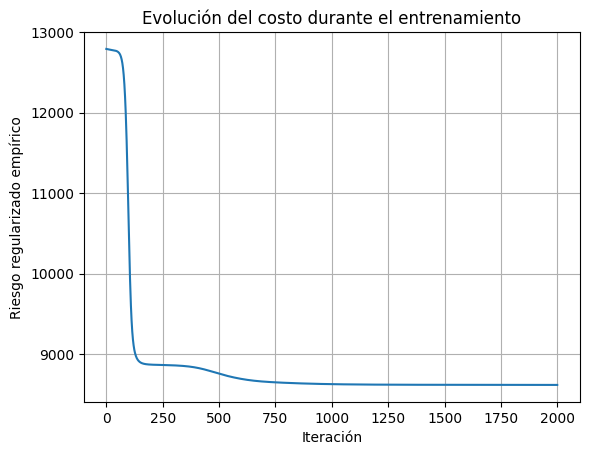

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iteración")
plt.ylabel("Riesgo regularizado empírico")
plt.title("Evolución del costo durante el entrenamiento")
plt.grid(True)
plt.show()

### (b.4)

Definimos a la interferencia como:

$$\hat{y}_{i,j}=p(\theta_j^T\cdot x_i)+(1-p)\bar{y}_i$$

En donde, $0\leq p\leq 1$ es un hiperparámetro que indica cuanto peso le
damos al aprendizaje y cuanto al valor medio. $\bar{y}_i$ indica la calificación promedio de la serie $i$.


In [ ]:
p=0.5

Y_pred_real = Y_mean + filter.predict()
Y_pred_real = np.clip(Y_pred_real, 0, 1)

rating = p * (Y_pred_real) + (1 - p) * Y_mean


[[0.56947368 0.56947368 0.56947368 ... 0.56947368 0.56947368 0.56947368]
 [0.65654762 0.65654762 0.65654762 ... 0.65654762 0.65654762 0.65654762]
 [0.65885167 0.65885167 0.65885167 ... 0.65885167 0.65885167 0.65885167]
 ...
 [0.4703125  0.4703125  0.4703125  ... 0.4703125  0.4703125  0.4703125 ]
 [0.66197531 0.66197531 0.66197531 ... 0.66197531 0.66197531 0.66197531]
 [0.67417417 0.67417417 0.67417417 ... 0.67417417 0.67417417 0.67417417]]


### (b.5)

Se genera una lista de las 10 mejores recomendaciones para el usuario creado previamente a partir de las predicciones del modelo. El proceso comienza localizando los scores predichos para el usuario dentro de la matriz rating. A continuación, se utiliza la Matriz Indicadora ($R$) para filtrar y excluir todos los ítems que el usuario ya ha calificado, quedándose solo con los ítems no vistos. De estos ítems no vistos, se clasifican los ratings predichos de mayor a menor y se seleccionan los índices correspondientes a las 10 puntuaciones más altas. Finalmente, se recuperan los títulos de estos 10 ítems del dataset original, se añade una columna con su rating predicho (escalado de vuelta al rango [0, 10]),y se imprime el resultado ordenado.

In [ ]:
n_recommend = 10

user_idx = user_rating_columns.tolist().index('123456')
scores_user = rating[:, user_idx]
mask_not_seen = R[:, user_idx] == 0
scores_user_not_seen = scores_user[mask_not_seen]
idx_not_seen = np.where(mask_not_seen)[0]
sorted_idx = np.argsort(scores_user_not_seen)[::-1]
top_idx = idx_not_seen[sorted_idx[:n_recommend]]

recomendations = anime.iloc[top_idx][['title']].copy()
recomendations['predicted_rating'] = scores_user[top_idx] * 10
recomendaciones = recomendations.sort_values(by='predicted_rating', ascending=False)
print(recomendations)

                                                  title  predicted_rating
2281                              spy x family season 3              10.0
2196  shinjiteita nakama-tachi ni dungeon okuchi de ...              10.0
2132                scooped up by an s-rank adventurer!              10.0
122                                      ame to kimi to              10.0
1649                       my dress-up darling season 2              10.0
1808                             one punch man season 3              10.0
2487            the fragrant flower blooms with dignity              10.0
237                                            bad girl              10.0
2100                               sakamoto days part 2              10.0
979   hell mode: yarikomizuki no gamer wa hai settei...              10.0
